<a href="https://colab.research.google.com/github/seobojung/ABCD-A/blob/20250414/yolo_v8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Ultralytics 패키지 설치
!pip install ultralytics

In [ ]:
# 2. 필요한 라이브러리 임포트
from ultralytics import YOLO
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO

In [ ]:
# 3. YOLOv8 모델 불러오기
model = YOLO('yolov8n.pt')  # 'n'은 nano 모델, 더 큰 모델은 's', 'm', 'l', 'x' 사용 가능

In [ ]:
# 4. 예시 이미지 다운로드
!wget https://ultralytics.com/images/bus.jpg -O sample.jpg

--2025-04-11 01:17:34--  https://ultralytics.com/images/bus.jpg
Resolving ultralytics.com (ultralytics.com)... 75.2.70.75, 99.83.190.102
Connecting to ultralytics.com (ultralytics.com)|75.2.70.75|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.ultralytics.com/images/bus.jpg [following]
--2025-04-11 01:17:34--  https://www.ultralytics.com/images/bus.jpg
Resolving www.ultralytics.com (www.ultralytics.com)... 104.18.40.102, 172.64.147.154, 2606:4700:4400::ac40:939a, ...
Connecting to www.ultralytics.com (www.ultralytics.com)|104.18.40.102|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/ultralytics/assets/releases/download/v0.0.0/bus.jpg [following]
--2025-04-11 01:17:34--  https://github.com/ultralytics/assets/releases/download/v0.0.0/bus.jpg
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request 

In [ ]:
# 5. PIL을 사용하여 이미지 로드
image = Image.open("sample.jpg")

In [ ]:
# 6. 객체 검출 수행
results = model(image)


0: 640x480 4 persons, 1 bus, 1 stop sign, 47.6ms
Speed: 34.0ms preprocess, 47.6ms inference, 338.3ms postprocess per image at shape (1, 3, 640, 480)


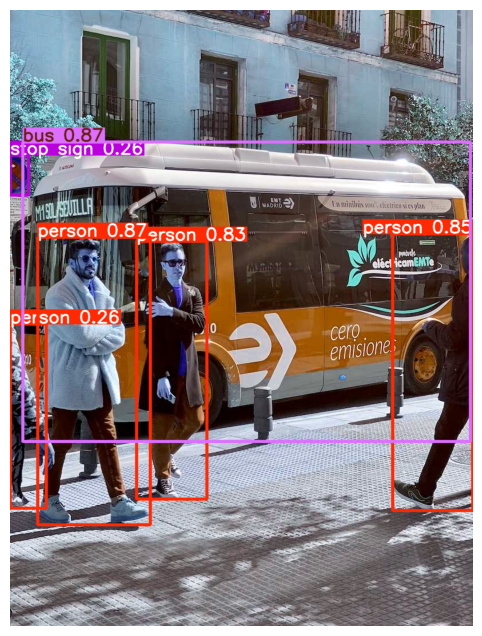

In [ ]:
# 7. 결과 시각화 (matplotlib 사용)
plt.figure(figsize=(12, 8))
plt.imshow(np.array(results[0].plot()))
plt.axis('off')
plt.show()

In [ ]:
# 8. 검출된 객체 정보 출력
for r in results:
    print("검출된 객체:", r.boxes.cls.tolist())
    print("신뢰도 점수:", r.boxes.conf.tolist())
    print("바운딩 박스 좌표:", r.boxes.xyxy.tolist())

검출된 객체: [5.0, 0.0, 0.0, 0.0, 0.0, 11.0]
신뢰도 점수: [0.8734485507011414, 0.8656912446022034, 0.8528353571891785, 0.8252248764038086, 0.26111239194869995, 0.25506994128227234]
바운딩 박스 좌표: [[22.87126922607422, 231.2772674560547, 805.0025634765625, 756.8403930664062], [48.55049133300781, 398.55218505859375, 245.34555053710938, 902.7026977539062], [669.472900390625, 392.1860656738281, 809.7201538085938, 877.0354614257812], [221.5172882080078, 405.79864501953125, 344.9706115722656, 857.53662109375], [0.0, 550.525146484375, 63.00693130493164, 873.44287109375], [0.05817067623138428, 254.4593963623047, 32.557411193847656, 324.8741455078125]]


In [ ]:
# 클래스 이름 가져오기 (선택 사항)
for c in r.boxes.cls:
    class_id = int(c)
    class_name = model.names[class_id]
    print(f"클래스 ID {class_id}: {class_name}")

클래스 ID 5: bus
클래스 ID 0: person
클래스 ID 0: person
클래스 ID 0: person
클래스 ID 0: person
클래스 ID 11: stop sign


In [ ]:
from google.colab import files

In [ ]:
# 파일 업로드 대화상자 표시
uploaded = files.upload()


Saving 다람쥐.webp to 다람쥐 (2).webp


In [ ]:
# 업로드된 파일 이름 출력
for filename in uploaded.keys():
    print(f'업로드된 파일: {filename}')

업로드된 파일: 다람쥐 (2).webp


In [ ]:
from PIL import Image
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# 모델 로드
model = YOLO('yolov8n.pt')

In [ ]:
# 업로드된 이미지 경로 (방법 1, 2에서 업로드한 경우)
image_path = '다람쥐.webp'  # 실제 파일명으로 변경하세요

In [ ]:
# 이미지 로드
image = Image.open(image_path)

In [ ]:
# 객체 검출 수행
results = model(image)


0: 448x640 1 cat, 42.3ms
Speed: 2.2ms preprocess, 42.3ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)


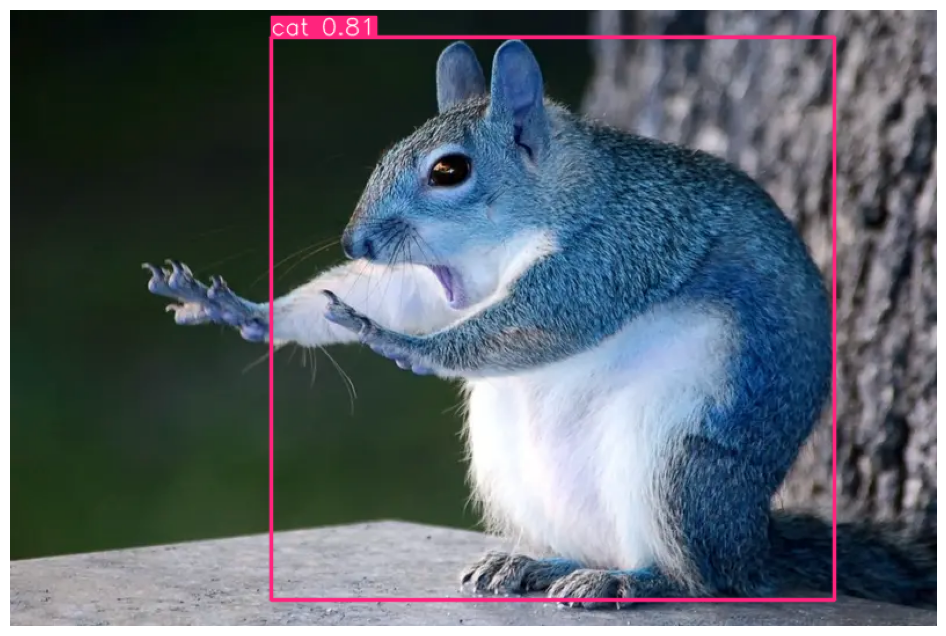

In [ ]:
# 결과 시각화
plt.figure(figsize=(12, 8))
plt.imshow(np.array(results[0].plot()))
plt.axis('off')
plt.show()

In [ ]:
# 2. 라이브러리 불러오기
from ultralytics import YOLO
from google.colab import files
import os, glob, base64
from IPython.display import HTML

In [ ]:
# 3. ffmpeg 설치 (avi → mp4 변환용)
!apt-get install ffmpeg -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.


In [ ]:
# 3. YOLOv8 모델 로드 (가벼운 모델 사용)
model = YOLO('yolov8n.pt')  # yolov8n, yolov8s, yolov8m 등 가능

In [ ]:
# 4. 동영상 업로드
print("📁 '도로 cctv.mp4' 파일을 업로드 해주세요:")
uploaded = files.upload()
video_path = next(iter(uploaded))  # 업로드한 첫 번째 파일 경로

📁 '도로 cctv.mp4' 파일을 업로드 해주세요:


Saving 도로 cctv.mp4 to 도로 cctv.mp4


In [ ]:
# 5. 객체 탐지 실행
model.predict(source=video_path, save=True)



WARNING ⚠️ inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/3000) /content/도로 cctv.mp4: 384x640 11 cars, 47.7ms
video 1/1 (frame 2/3000) /content/도로 cctv.mp4: 384x640 11 cars, 7.0ms
video 1/1 (frame 3/3000) /content/도로 cctv.mp4: 384x640 12 cars, 6.9ms
video 1/1 (frame 4/3000) /content/도로 cctv.mp4: 384x640 11 cars, 6.9ms
video 1/1 (frame 5/3000) /content/도로 cctv.mp4: 384x640 11 cars, 6.7ms
video 1/1 (frame 6/3000) /content/도로 cctv.mp4: 384x640 11 cars, 7.0ms
video 1/1 (frame 7/3000) /content/도

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

In [ ]:
# 7. 결과 파일 경로 탐색 (avi 포함)
latest_dir = sorted(glob.glob('runs/detect/predict*'), key=os.path.getmtime)[-1]
video_list = [f for f in os.listdir(latest_dir) if f.lower().endswith(('.avi', '.mp4'))]

if video_list:
    output_path = os.path.join(latest_dir, video_list[0])
    print("✅ 탐지된 결과 영상:", output_path)
else:
    raise FileNotFoundError("❗️탐지 결과 영상이 없습니다.")

✅ 탐지된 결과 영상: runs/detect/predict3/도로 cctv.avi


In [ ]:

# 8. avi → mp4 변환 (브라우저 재생 호환)
mp4_path = output_path.replace('.avi', '.mp4')
!ffmpeg -i "{output_path}" -vcodec libx264 -acodec aac "{mp4_path}"

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
# 9. 동영상 재생 함수
def play_video(path):
    with open(path, 'rb') as f:
        video_data = f.read()
    video_base64 = base64.b64encode(video_data).decode()
    return HTML(f"""
    <video width="640" height="480" controls>
        <source src="data:video/mp4;base64,{video_base64}" type="video/mp4">
    </video>""")

In [ ]:
# 10. 결과 영상 재생
play_video(mp4_path)